# Bayesian Decision and Uncertainty: Skin Lesion Triage

Melanoma-vs-benign triage on the HAM10000 dataset. The workflow excludes `bcc` and `akiec`
(malignant / pre-malignant categories that are neither melanoma nor benign and would blur a clean
melanoma-vs-benign task), uses lesion-aware **and** class-stratified splitting, fits an
HSV-histogram + GMM Bayesian classical baseline, compares it against a fine-tuned EfficientNet-B0
with MC-Dropout uncertainty, and evaluates both under **asymmetric-cost Bayesian decision rules**
on the same held-out internal test split.

Key design choices:
- **Natural class prevalence is kept** (melanoma is a small minority of lesions). The point of the
  Bayesian decision-theory framing is that the *true* prior and an *asymmetric cost* â€” not
  artificial class balancing â€” drive the decision threshold.
- **The classical GMM pipeline is taken all the way to a decision**: MAP threshold, asymmetric-cost
  threshold, confusion matrices, and a reliability diagram, exactly as for the deep model.
- **A single cost-sweep table and a per-lesion prediction file** let classical-vs-deep decisions be
  compared directly on the same test lesions.
- **`FINE_TUNE_BACKBONE` toggle** selects between a frozen EfficientNet-B0 (only the classification
  head trained) and a two-stage recipe that additionally fine-tunes the last blocks at a low
  learning rate; the latter is the default and usually improves AUC.

## Setup and Reproducible Configuration

In [1]:
import os
import random
import warnings
import json
import platform
from copy import deepcopy
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
from PIL import Image
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    auc, brier_score_loss, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights

warnings.filterwarnings("ignore")

import time
NOTEBOOK_START_TIME = time.time()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

GPU_COUNT = torch.cuda.device_count()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Per-thread device: the multi-seed driver runs one seed per GPU in parallel threads.
# Every model/tensor moves to cur_device(); the main thread falls back to the default `device`.
import threading
_device_tls = threading.local()
_init_lock = threading.Lock()          # serialize per-seed reseed + model construction only
def cur_device():
    return getattr(_device_tls, "device", device)
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### Configuration

Hyperparameters, the GMM search range, and the asymmetric cost matrix â€” logged to `run_config.json` at the end of the run.

In [2]:
# The image cache below (cell "Dataset, transforms, loaders") removes the JPEG-decode
# bottleneck, so training becomes GPU-bound and the second T4 is worth using. DataParallel
# then splits each batch across both GPUs. Set to False to fall back to a single GPU.
USE_DATA_PARALLEL = False   # DataParallel serializes a tiny model on Python overhead + drops AMP; one T4 + the image cache is faster
BATCH_SIZE = 256 if torch.cuda.is_available() else 32   # 128/GPU under DataParallel; amortizes launch/transfer overhead
NUM_WORKERS = min(8, os.cpu_count() or 8)
PREFETCH_FACTOR = 2 if NUM_WORKERS > 0 else None   # smaller in-flight buffer -> less host RAM

# Staged training: fit the head first, then optionally fine-tune the last EfficientNet blocks.
# FINE_TUNE_BACKBONE=False keeps the backbone frozen (only the classification head trains);
# True (default) additionally fine-tunes the last blocks at a low LR, which usually improves AUC.
FINE_TUNE_BACKBONE = True
SEEDS = [42, 1, 2]             # multi-seed robustness; SEEDS[0] drives every figure and the primary CSVs
HEAD_EPOCHS = 30               # max epochs per stage; early stopping usually halts well before this
FINE_TUNE_EPOCHS = 30
EARLY_STOP_PATIENCE = 5        # halt a stage after this many epochs with no val-AUC improvement
UNFREEZE_LAST_BLOCKS = 2
HEAD_LR = 1e-3
FINE_TUNE_LR = 1e-5
WEIGHT_DECAY = 1e-4
MC_PASSES = 30

# Feature and cost configuration, recorded explicitly for reproducibility
# (feature type, GMM component search range, and cost matrix).
HSV_BINS = 32
GMM_MAX_COMPONENTS = 60          # search range for BIC-based component selection
GMM_FIT_SUBSAMPLE = 2000         # class-stratified subsample of the fit split

# Primary asymmetric cost matrix used for the headline decision throughout the notebook.
# A missed melanoma (false negative) is treated as far more costly than an unnecessary
# referral (false positive) â€” this drives the asymmetric decision threshold below.
FN_COST = 10
FP_COST = 1
COST_SWEEP = [(1, 1), (5, 1), (10, 1), (20, 1)]  # (l_fn, l_fp) ratios for the fuller sweep

print(f"Using device: {device}")
print(f"CUDA devices: {GPU_COUNT}")
for i in range(GPU_COUNT):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
print(f"Batch size: {BATCH_SIZE}; workers: {NUM_WORKERS}; prefetch: {PREFETCH_FACTOR}")
print(f"Head epochs: {HEAD_EPOCHS}; fine-tune epochs: {FINE_TUNE_EPOCHS} (enabled={FINE_TUNE_BACKBONE}); last blocks: {UNFREEZE_LAST_BLOCKS}")
print(f"Primary cost matrix -> FN_COST:{FN_COST}, FP_COST:{FP_COST}")
print(f"Outputs directory: {OUTPUT_DIR.resolve()}")

# Record package versions for reproducibility.
print("\nPackage versions:")
print(f"  python={platform.python_version()}, torch={torch.__version__}, "
      f"sklearn={sklearn.__version__}, opencv={cv2.__version__}, "
      f"pandas={pd.__version__}, numpy={np.__version__}")

Using device: cuda
CUDA devices: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Batch size: 256; workers: 4; prefetch: 2
Head epochs: 30; fine-tune epochs: 30 (enabled=True); last blocks: 2
Primary cost matrix -> FN_COST:10, FP_COST:1
Outputs directory: /kaggle/working/outputs

Package versions:
  python=3.12.12, torch=2.10.0+cu128, sklearn=1.6.1, opencv=4.13.0, pandas=2.3.3, numpy=2.0.2


## Load and Filter HAM10000

The notebook expects the Kaggle HAM10000 mirror (`kmader/skin-cancer-mnist-ham10000`):
`HAM10000_metadata.csv` plus `HAM10000_images_part_1/2`. It builds all fit/val/cal/test splits
from that training pool with lesion-aware grouping so images of the same lesion never cross splits.

Class counts are naturally imbalanced (melanoma is a small minority); we keep that prevalence
rather than balancing it, and report it explicitly below.

Training pool (HAM10000_metadata.csv):
dx
nv      6705
mel     1113
bkl     1099
vasc     142
df       115
Name: count, dtype: int64
  rows=9,174, melanoma prevalence=0.121


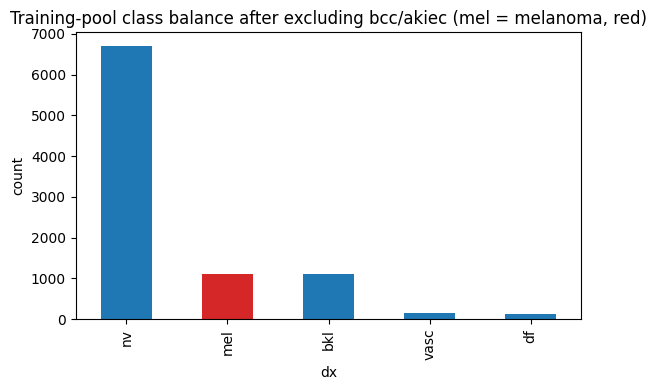

In [3]:
import glob

def find_file(filename, search_root="/kaggle/input"):
    matches = glob.glob(os.path.join(search_root, "**", filename), recursive=True)
    return matches[0] if matches else None

def find_dir(dirname, search_root="/kaggle/input"):
    matches = [m for m in glob.glob(os.path.join(search_root, "**", dirname), recursive=True) if os.path.isdir(m)]
    return matches[0] if matches else None

# Robust path discovery: works regardless of the exact Kaggle dataset slug as long as the
# HAM10000 metadata and image folder names are present.
TRAIN_METADATA_CSV = find_file("HAM10000_metadata.csv")
TRAIN_IMG_DIRS = [d for d in [find_dir("HAM10000_images_part_1"), find_dir("HAM10000_images_part_2")] if d]
if TRAIN_METADATA_CSV is None or not TRAIN_IMG_DIRS:
    raise FileNotFoundError(
        "Could not find HAM10000_metadata.csv / HAM10000_images_part_1/2 under /kaggle/input. "
        "Attach the HAM10000 dataset (kmader/skin-cancer-mnist-ham10000)."
    )

def load_metadata(csv_path, img_dirs):
    frame = pd.read_csv(csv_path)
    frame = frame[~frame["dx"].isin(["bcc", "akiec"])].reset_index(drop=True)
    frame["target"] = (frame["dx"] == "mel").astype(int)

    def resolve(image_id):
        for img_dir in img_dirs:
            path = os.path.join(img_dir, f"{image_id}.jpg")
            if os.path.exists(path):
                return path
        raise FileNotFoundError(f"Image not found: {image_id}")

    frame["image_path"] = frame["image_id"].map(resolve)
    return frame

trainpool_df = load_metadata(TRAIN_METADATA_CSV, TRAIN_IMG_DIRS)
print("Training pool (HAM10000_metadata.csv):")
print(trainpool_df["dx"].value_counts())
print(f"  rows={len(trainpool_df):,}, melanoma prevalence={trainpool_df['target'].mean():.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
trainpool_df["dx"].value_counts().plot(
    kind="bar", ax=ax,
    color=["#d62728" if c == "mel" else "#1f77b4" for c in trainpool_df["dx"].value_counts().index],
)
ax.set_ylabel("count")
ax.set_title("Training-pool class balance after excluding bcc/akiec (mel = melanoma, red)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_balance.png", dpi=160)
plt.show()

## Reproducible, Leakage-Free, Stratified Split

The HAM10000 training pool is split into four disjoint, lesion-grouped, class-stratified sets with
`StratifiedGroupKFold` (stratifies on `target` while keeping every image of a given lesion in the
same split, so no lesion's images end up split across two sets):

- **`fit`** â€” trains the GMMs and the EfficientNet head/backbone.
- **`val`** â€” used only to pick the best training checkpoint (early-stopping proxy). Never used for
  calibration or final metrics.
- **`cal`** â€” used only to fit Platt scaling and to pick sensitivity-based operating thresholds.
- **`test`** â€” touched only in the final evaluation/comparison cells.

In [4]:
# Lesion-aware, class-stratified split: three successive StratifiedGroupKFold(5) peels
# (test, then calibration, then validation) keep every lesion_id in exactly one split.
def make_splits(pool_df, seed):
    sgkf_test = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    rem_idx, test_idx = next(sgkf_test.split(pool_df, pool_df["target"], groups=pool_df["lesion_id"]))
    rem = pool_df.iloc[rem_idx].reset_index(drop=True)
    test = pool_df.iloc[test_idx].reset_index(drop=True)

    sgkf_cal = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    fv_idx, cal_idx = next(sgkf_cal.split(rem, rem["target"], groups=rem["lesion_id"]))
    fitval = rem.iloc[fv_idx].reset_index(drop=True)
    cal = rem.iloc[cal_idx].reset_index(drop=True)

    sgkf_val = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    f_idx, v_idx = next(sgkf_val.split(fitval, fitval["target"], groups=fitval["lesion_id"]))
    fit = fitval.iloc[f_idx].reset_index(drop=True)
    val = fitval.iloc[v_idx].reset_index(drop=True)

    groups = {"fit": set(fit["lesion_id"]), "val": set(val["lesion_id"]),
              "cal": set(cal["lesion_id"]), "test": set(test["lesion_id"])}
    names = list(groups)
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            assert groups[names[i]].isdisjoint(groups[names[j]]), f"Leakage between {names[i]} and {names[j]}"
    return fit, val, cal, test

# Primary split (SEEDS[0]) drives every figure and the primary-seed CSVs.
fit_df, val_df, cal_df, test_df = make_splits(trainpool_df, SEEDS[0])

print("Split sizes and class prevalence (should be similar across splits if stratification worked):")
for name, d in [("fit", fit_df), ("val", val_df), ("cal", cal_df), ("test", test_df)]:
    print(f"  {name:5s}: rows={len(d):5d}, lesions={d['lesion_id'].nunique():5d}, prevalence={d['target'].mean():.3f}")

split_records = []
for name, d in [("fit", fit_df), ("val", val_df), ("cal", cal_df), ("test", test_df)]:
    tmp = d[["image_id", "lesion_id", "dx", "target"]].copy()
    tmp["split"] = name
    split_records.append(tmp)
pd.concat(split_records, ignore_index=True).to_csv(OUTPUT_DIR / "split_assignment.csv", index=False)
print(f"Saved {OUTPUT_DIR / 'split_assignment.csv'}")


Split sizes and class prevalence (should be similar across splits if stratification worked):
  fit  : rows= 4750, lesions= 3541, prevalence=0.132
  val  : rows= 1146, lesions=  884, prevalence=0.125
  cal  : rows= 1418, lesions= 1107, prevalence=0.100
  test : rows= 1860, lesions= 1383, prevalence=0.108
Saved outputs/split_assignment.csv


## Classical Baseline: HSV Histograms + GMM

**Theory â€” Bayes decision rule.** For class-conditional densities $p(x \mid \text{mel})$, $p(x \mid \text{benign})$
estimated by the GMMs below and priors $\pi_{\text{mel}}, \pi_{\text{benign}}$ estimated from the training
prevalence, Bayes' rule gives the posterior

$$P(\text{mel} \mid x) = \frac{p(x\mid\text{mel})\,\pi_{\text{mel}}}{p(x\mid\text{mel})\,\pi_{\text{mel}} + p(x\mid\text{benign})\,\pi_{\text{benign}}}.$$

Under 0/1 loss, the optimal decision is MAP: predict melanoma when $P(\text{mel}\mid x) \ge 0.5$. Under an
asymmetric cost matrix with $L_{FN}$ (cost of missing a melanoma) and $L_{FP}$ (cost of an unnecessary
referral), the expected-cost-minimizing threshold shifts to

$$\tau^\* = \frac{L_{FP}}{L_{FP} + L_{FN}}.$$

With $L_{FN}=10, L_{FP}=1$ this gives $\tau^\* \approx 0.091$ â€” the classifier should flag anything above a
~9% estimated melanoma probability, trading specificity for a much lower false-negative rate. This is the
concrete decision the notebook reports.

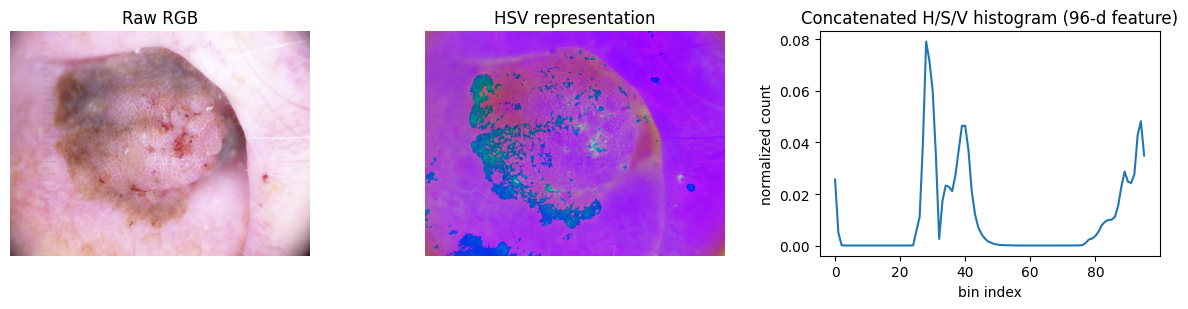

In [5]:
def extract_hsv_hist(path, bins=HSV_BINS):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist_h = cv2.calcHist([hsv], [0], None, [bins], [0, 180]).flatten()
    hist_s = cv2.calcHist([hsv], [1], None, [bins], [0, 256]).flatten()
    hist_v = cv2.calcHist([hsv], [2], None, [bins], [0, 256]).flatten()
    features = np.concatenate([hist_h, hist_s, hist_v]).astype(np.float32)
    return features / (features.sum() + 1e-7)

# Visualize the raw image, its HSV representation, and the resulting histogram feature.
_sample_path = fit_df["image_path"].iloc[0]
_sample_bgr = cv2.imread(_sample_path)
_sample_rgb = cv2.cvtColor(_sample_bgr, cv2.COLOR_BGR2RGB)
_sample_hsv = cv2.cvtColor(_sample_bgr, cv2.COLOR_BGR2HSV)
_sample_feat = extract_hsv_hist(_sample_path)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].imshow(_sample_rgb); axes[0].set_title("Raw RGB"); axes[0].axis("off")
axes[1].imshow(_sample_hsv); axes[1].set_title("HSV representation"); axes[1].axis("off")
axes[2].plot(_sample_feat)
axes[2].set_title(f"Concatenated H/S/V histogram ({3*HSV_BINS}-d feature)")
axes[2].set_xlabel("bin index"); axes[2].set_ylabel("normalized count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "raw_vs_processed_feature.png", dpi=160)
plt.show()

In [6]:
from sklearn.linear_model import LogisticRegression

def fit_calibrated_gmm(fit_frame, cal_frame, seed):
    """Per-class HSV GMMs with BIC component selection, then Platt-calibrate the GMM log-odds
    on the calibration split so the classical posterior is calibrated like the deep model."""
    seed_everything(seed)
    n = min(GMM_FIT_SUBSAMPLE, len(fit_frame))
    sub, _ = train_test_split(fit_frame, train_size=n, stratify=fit_frame["target"], random_state=seed)
    Xf = np.stack([extract_hsv_hist(p) for p in sub["image_path"]])
    yf = sub["target"].to_numpy()

    bic_scores, class_max_k, ks = [], [], []
    for cls in range(2):
        Xc = Xf[yf == cls]
        max_k = min(GMM_MAX_COMPONENTS, len(Xc))
        class_max_k.append(max_k)
        bic = [GaussianMixture(n_components=k, covariance_type="diag", random_state=seed).fit(Xc).bic(Xc)
               for k in range(1, max_k + 1)]
        bic_scores.append(bic)
        ks.append(int(np.argmin(bic)) + 1)
    k_benign, k_mel = ks

    gmm_benign = GaussianMixture(n_components=k_benign, covariance_type="diag", random_state=seed).fit(Xf[yf == 0])
    gmm_mel = GaussianMixture(n_components=k_mel, covariance_type="diag", random_state=seed).fit(Xf[yf == 1])
    prior_mel = yf.mean()
    prior_logodds = np.log((prior_mel + 1e-10) / (1 - prior_mel + 1e-10))

    def gmm_logodds(X):
        return gmm_mel.score_samples(X) - gmm_benign.score_samples(X) + prior_logodds

    # Platt scaling of the GMM log-odds, fit ONLY on the calibration split (the split the deep model uses too).
    Xcal = np.stack([extract_hsv_hist(p) for p in cal_frame["image_path"]])
    ycal = cal_frame["target"].to_numpy()
    platt = LogisticRegression(C=1e6, solver="lbfgs").fit(gmm_logodds(Xcal).reshape(-1, 1), ycal)

    def prob_cal(X):
        return platt.predict_proba(gmm_logodds(X).reshape(-1, 1))[:, 1]

    def prob_raw(X):
        return 1.0 / (1.0 + np.exp(-gmm_logodds(X)))

    return {"prob_cal": prob_cal, "prob_raw": prob_raw, "k_benign": k_benign, "k_mel": k_mel,
            "bic_scores": bic_scores, "class_max_k": class_max_k, "n_fit": n}

# Fit the classical baseline for the primary seed; expose the globals the figures/config cells use.
_gmm = fit_calibrated_gmm(fit_df, cal_df, SEEDS[0])
gmm_prob_cal, gmm_prob_raw = _gmm["prob_cal"], _gmm["prob_raw"]
k_benign, k_mel = _gmm["k_benign"], _gmm["k_mel"]
bic_scores, class_max_k, _gmm_fit_n = _gmm["bic_scores"], _gmm["class_max_k"], _gmm["n_fit"]

X_val_gmm = np.stack([extract_hsv_hist(p) for p in val_df["image_path"]]); y_val_gmm = val_df["target"].to_numpy()
X_test_gmm = np.stack([extract_hsv_hist(p) for p in test_df["image_path"]]); y_test_gmm = test_df["target"].to_numpy()

gmm_probs_val = gmm_prob_cal(X_val_gmm)
gmm_probs_test = gmm_prob_cal(X_test_gmm)         # Platt-calibrated: used for all decisions and ECE
gmm_probs_test_raw = gmm_prob_raw(X_test_gmm)     # uncalibrated: reliability before/after only

X_cal_gmm = np.stack([extract_hsv_hist(p) for p in cal_df["image_path"]]); y_cal_gmm = cal_df["target"].to_numpy()
gmm_probs_cal = gmm_prob_cal(X_cal_gmm)           # calibration-split probs for operating-point threshold selection

print(f"Selected GMM components via BIC: benign K={k_benign}, melanoma K={k_mel} "
      f"(search range 1-{GMM_MAX_COMPONENTS})")
for name, k, mk in [("benign", k_benign, class_max_k[0]), ("melanoma", k_mel, class_max_k[1])]:
    if k >= mk - 2:
        print(f"  WARNING: {name} K={k} is near the search boundary (max {mk}) -- inspect the BIC curve below.")

gmm_fpr, gmm_tpr, _ = roc_curve(y_test_gmm, gmm_probs_test)
print(f"GMM TEST-set AUC (calibrated; ranking identical to raw): {auc(gmm_fpr, gmm_tpr):.3f}")


Selected GMM components via BIC: benign K=28, melanoma K=8 (search range 1-60)
GMM TEST-set AUC (calibrated; ranking identical to raw): 0.805


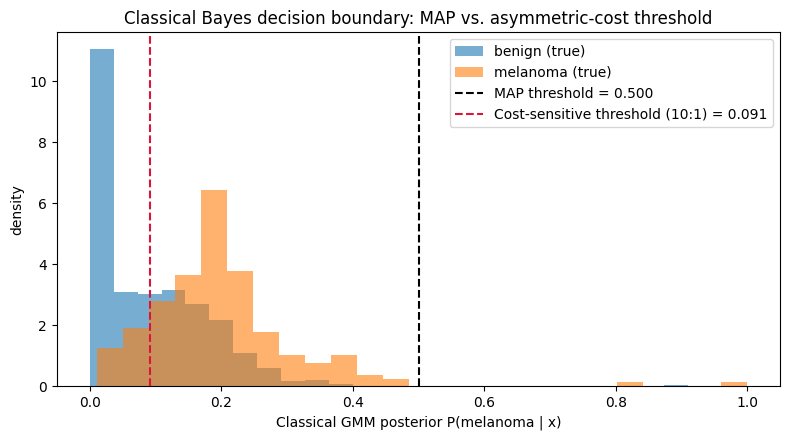

In [7]:
# Visualize the Bayes decision boundary: per-class posterior histograms with the MAP and
# asymmetric-cost thresholds overlaid.
tau_map = 0.5
tau_cost = FP_COST / (FP_COST + FN_COST)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(gmm_probs_test[y_test_gmm == 0], bins=25, alpha=0.6, density=True, label="benign (true)")
ax.hist(gmm_probs_test[y_test_gmm == 1], bins=25, alpha=0.6, density=True, label="melanoma (true)")
ax.axvline(tau_map, color="black", linestyle="--", label=f"MAP threshold = {tau_map:.3f}")
ax.axvline(tau_cost, color="crimson", linestyle="--",
           label=f"Cost-sensitive threshold ({FN_COST}:{FP_COST}) = {tau_cost:.3f}")
ax.set_xlabel("Classical GMM posterior P(melanoma | x)")
ax.set_ylabel("density")
ax.set_title("Classical Bayes decision boundary: MAP vs. asymmetric-cost threshold")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bayes_decision_boundary.png", dpi=160)
plt.show()

### Classical decision rule: MAP vs. asymmetric cost (test set)

The same decision-theoretic machinery used for the deep model is applied to the classical GMM:
derive the decision threshold from the asymmetric cost matrix, compare it against the MAP (0.5)
threshold, and evaluate the resulting decisions with a confusion matrix and reliability diagram
(further down). The cell below builds the classical cost-sweep table on the held-out test set.

In [8]:
def metrics_at_threshold(probs, y_true, tau):
    preds = (probs >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    return {
        "sensitivity": sensitivity, "specificity": specificity, "precision": precision,
        "referral_rate": preds.mean(), "false_negatives": int(fn), "false_positives": int(fp),
        "true_negatives": int(tn), "true_positives": int(tp),
    }

def evaluate_threshold(probs, y_true, l_fn, l_fp, model_name):
    tau = l_fp / (l_fp + l_fn)
    row = {"model": model_name, "cost_ratio_fn_fp": f"{l_fn}:{l_fp}", "threshold": tau}
    row.update(metrics_at_threshold(probs, y_true, tau))
    return row

# Cost-sweep table for the classical model on the test split. Deep-model rows are appended to
# this table once the deep predictions are computed in the calibration section below.
classical_cost_rows = [
    evaluate_threshold(gmm_probs_test, y_test_gmm, l_fn, l_fp, "classical_gmm")
    for l_fn, l_fp in COST_SWEEP
]
classical_cost_df = pd.DataFrame(classical_cost_rows)
print("Classical GMM: MAP (1:1) vs. asymmetric-cost thresholds on the held-out test set")
print(classical_cost_df.to_string(index=False, formatters={
    "threshold": "{:.3f}".format, "sensitivity": "{:.3f}".format,
    "specificity": "{:.3f}".format, "precision": "{:.3f}".format, "referral_rate": "{:.3f}".format,
}))

Classical GMM: MAP (1:1) vs. asymmetric-cost thresholds on the held-out test set
        model cost_ratio_fn_fp threshold sensitivity specificity precision referral_rate  false_negatives  false_positives  true_negatives  true_positives
classical_gmm              1:1     0.500       0.010       0.997     0.286         0.004              198                5            1655               2
classical_gmm              5:1     0.167       0.635       0.808     0.285         0.240               73              319            1341             127
classical_gmm             10:1     0.091       0.875       0.572     0.198         0.476               25              711             949             175
classical_gmm             20:1     0.048       0.950       0.448     0.172         0.595               10              916             744             190


## EfficientNet-B0 with MC Dropout

**`FINE_TUNE_BACKBONE`:** with `False`, the EfficientNet-B0 backbone stays frozen and only the
classification head is trained. With `True` (default) the notebook additionally unfreezes the last
two blocks and fine-tunes them at a low learning rate, which typically improves AUC. Set the flag
in the configuration cell and re-run to switch between the two.

### Dataset, transforms, and data loaders

In [9]:
# Decode + resize every image once into a single shared uint8 array, so training never
# re-reads a JPEG. One contiguous ndarray (not a dict of arrays) stays fork/copy-on-write
# friendly for DataLoader workers. ~9k x 224 x 224 x 3 uint8 ~= 1.4 GB.
IMG_SIZE = 224
_all_paths = list(dict.fromkeys(trainpool_df["image_path"]))
PATH_TO_IDX = {p: i for i, p in enumerate(_all_paths)}
IMAGE_ARRAY = np.zeros((len(_all_paths), IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
_n = len(_all_paths)
_t0 = time.time()
for _p, _i in PATH_TO_IDX.items():
    IMAGE_ARRAY[_i] = np.asarray(Image.open(_p).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
    if (_i + 1) % 1000 == 0 or _i + 1 == _n:
        print(f"\r  caching images: {_i + 1:,}/{_n:,} ({100 * (_i + 1) / _n:4.0f}%)", end="", flush=True)
print(f"\nCached {_n:,} resized images ({IMAGE_ARRAY.nbytes / 1e9:.2f} GB) in {time.time() - _t0:.0f}s")

class HAMDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.fromarray(IMAGE_ARRAY[PATH_TO_IDX[row["image_path"]]])
        label = torch.tensor(row["target"], dtype=torch.float32)
        if self.transform is not None:
            image = self.transform(image)
        return image, label

weights = EfficientNet_B0_Weights.IMAGENET1K_V1
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Images are already IMG_SIZE in the cache, so no Resize here. RandomRotation/ColorJitter
# stay on the CPU workers but are far cheaper than the JPEG decode they replace.
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": False,   # pinned buffers x many concurrent loaders overflow host RAM
    "persistent_workers": NUM_WORKERS > 0,
}
if NUM_WORKERS > 0:
    loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

# One loader per split: fit uses training augmentation, the others are eval-only.
def build_loaders(fit_frame, val_frame, cal_frame, test_frame, num_workers=None, gen=None):
    kw = dict(loader_kwargs)
    if num_workers is not None:            # fewer workers per run when two seeds share the CPUs
        kw["num_workers"] = num_workers
        kw["persistent_workers"] = num_workers > 0
        if num_workers > 0:
            kw["prefetch_factor"] = PREFETCH_FACTOR
        else:
            kw.pop("prefetch_factor", None)
    return (
        DataLoader(HAMDataset(fit_frame, transform_train), batch_size=BATCH_SIZE, shuffle=True, generator=gen, **kw),
        DataLoader(HAMDataset(val_frame, transform_eval), batch_size=BATCH_SIZE, shuffle=False, **kw),
        DataLoader(HAMDataset(cal_frame, transform_eval), batch_size=BATCH_SIZE, shuffle=False, **kw),
        DataLoader(HAMDataset(test_frame, transform_eval), batch_size=BATCH_SIZE, shuffle=False, **kw),
    )

fit_loader, val_loader, cal_loader, test_loader = build_loaders(fit_df, val_df, cal_df, test_df)


  caching images: 9,174/9,174 ( 100%)
Cached 9,174 resized images (1.38 GB) in 105s


### Training helper functions

In [10]:
def unwrap_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model

def set_backbone_trainable(model, trainable=False, last_blocks=0):
    base = unwrap_model(model)
    for param in base.features.parameters():
        param.requires_grad = False
    if trainable and last_blocks > 0:
        blocks = list(base.features.children())
        for block in blocks[-last_blocks:]:
            for param in block.parameters():
                param.requires_grad = True
    for param in base.classifier.parameters():
        param.requires_grad = True

def make_optimizer(model, lr):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(params, lr=lr, weight_decay=WEIGHT_DECAY)

def predict_probs(model, loader):
    model.eval()
    probs = []
    targets = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(cur_device(), non_blocking=True)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                logits = model(images).squeeze(1)
            probs.append(torch.sigmoid(logits).float().cpu().numpy())
            targets.extend(labels.numpy())
    return np.concatenate(probs), np.asarray(targets)

def train_one_epoch(model, loader, criterion, optimizer, scaler, stage="", epoch=0, batch_progress=True):
    model.train()
    total_loss = 0.0
    n_batches = len(loader)
    for b, (images, labels) in enumerate(loader, 1):
        images = images.to(cur_device(), non_blocking=True)
        labels = labels.to(cur_device(), non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        if batch_progress:
            print(f"\r  {stage} epoch {epoch:02d}: batch {b:>3}/{n_batches} - loss {total_loss / b:.4f}",
                  end="", flush=True)
    if batch_progress:
        print("\r" + " " * 70 + "\r", end="")  # clear the in-epoch line before the summary
    return total_loss / len(loader)

def build_model():
    m = models.efficientnet_b0(weights=weights)
    m.classifier = nn.Sequential(nn.Dropout(p=0.5, inplace=False), nn.Linear(1280, 1))
    m = m.to(cur_device())
    if USE_DATA_PARALLEL and GPU_COUNT >= 2:
        m = nn.DataParallel(m)
    return m

def _train_stage(model, fit_loader, val_loader, max_epochs, lr, stage, patience, history, best,
                 tag="", batch_progress=True):
    criterion = nn.BCEWithLogitsLoss()
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
    optimizer = make_optimizer(model, lr)
    no_improve = 0
    stage_start = time.time()
    for epoch in range(1, max_epochs + 1):
        loss = train_one_epoch(model, fit_loader, criterion, optimizer, scaler, stage, epoch, batch_progress)
        val_probs_epoch, val_targets_epoch = predict_probs(model, val_loader)
        val_auc_epoch = roc_auc_score(val_targets_epoch, val_probs_epoch)
        history.append({"stage": stage, "epoch": epoch, "loss": loss, "val_auc": val_auc_epoch})
        if val_auc_epoch > best["auc"]:
            best["auc"] = val_auc_epoch
            best["state"] = deepcopy(unwrap_model(model).state_dict())
            no_improve = 0
            flag = "*"
        else:
            no_improve += 1
            flag = f"(no-improve {no_improve}/{patience})"
        print(f"{tag}{stage} {epoch:02d}/{max_epochs} - loss {loss:.4f} - val_auc {val_auc_epoch:.4f} {flag}",
              flush=True)
        if no_improve >= patience:
            print(f"{tag}  early stop: {stage} stage halted after {epoch} epochs", flush=True)
            break
    return time.time() - stage_start

def train_efficientnet(fit_loader, val_loader, seed, tag="", batch_progress=True):
    """Two-stage training (head, then optional last-block fine-tune) with early stopping on val AUC.
    Returns the best-checkpoint model, best val AUC, history frame, and per-stage seconds."""
    with _init_lock:                       # keep reseed + head init atomic when seeds run in parallel
        seed_everything(seed)
        model = build_model()
    history = []
    best = {"auc": -np.inf, "state": None}
    set_backbone_trainable(model, trainable=False)
    head_sec = _train_stage(model, fit_loader, val_loader, HEAD_EPOCHS, HEAD_LR, "head",
                            EARLY_STOP_PATIENCE, history, best, tag, batch_progress)
    ft_sec = 0.0
    if FINE_TUNE_BACKBONE:
        set_backbone_trainable(model, trainable=True, last_blocks=UNFREEZE_LAST_BLOCKS)
        ft_sec = _train_stage(model, fit_loader, val_loader, FINE_TUNE_EPOCHS, FINE_TUNE_LR, "fine_tune",
                              EARLY_STOP_PATIENCE, history, best, tag, batch_progress)
    unwrap_model(model).load_state_dict(best["state"])
    return model, best["auc"], pd.DataFrame(history), {"head": head_sec, "fine_tune": ft_sec}


### Model and two-stage training loop

Build EfficientNet-B0 with an MC-Dropout head, train the head, then optionally fine-tune the last blocks. The best checkpoint is chosen on the val split.

In [11]:
# Train the primary-seed model (SEEDS[0]) that produces every figure below.
model, best_auc, history_df, _timings = train_efficientnet(fit_loader, val_loader, SEEDS[0])
head_train_seconds, fine_tune_seconds = _timings["head"], _timings["fine_tune"]
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
print(f"Best val-set AUC during training/model-selection (seed {SEEDS[0]}): {best_auc:.4f}")
print(f"Head time: {head_train_seconds/60:.1f} min; fine-tune time: {fine_tune_seconds/60:.1f} min")
print(f"Saved {OUTPUT_DIR / 'training_history.csv'}")


head 01/30 - loss 0.4903 - val_auc 0.5720 *                           
head 02/30 - loss 0.4187 - val_auc 0.7171 *                           
head 03/30 - loss 0.3784 - val_auc 0.7710 *                           
head 04/30 - loss 0.3665 - val_auc 0.7916 *                           
head 05/30 - loss 0.3520 - val_auc 0.8013 *                           
head 06/30 - loss 0.3491 - val_auc 0.8144 *                           
head 07/30 - loss 0.3385 - val_auc 0.8197 *                           
head 08/30 - loss 0.3347 - val_auc 0.8267 *                           
head 09/30 - loss 0.3338 - val_auc 0.8308 *                           
head 10/30 - loss 0.3264 - val_auc 0.8325 *                           
head 11/30 - loss 0.3222 - val_auc 0.8319 (no-improve 1/5)            
head 12/30 - loss 0.3144 - val_auc 0.8348 *                           
head 13/30 - loss 0.3225 - val_auc 0.8409 *                           
head 14/30 - loss 0.3150 - val_auc 0.8426 *                           
head 1

### Training curves

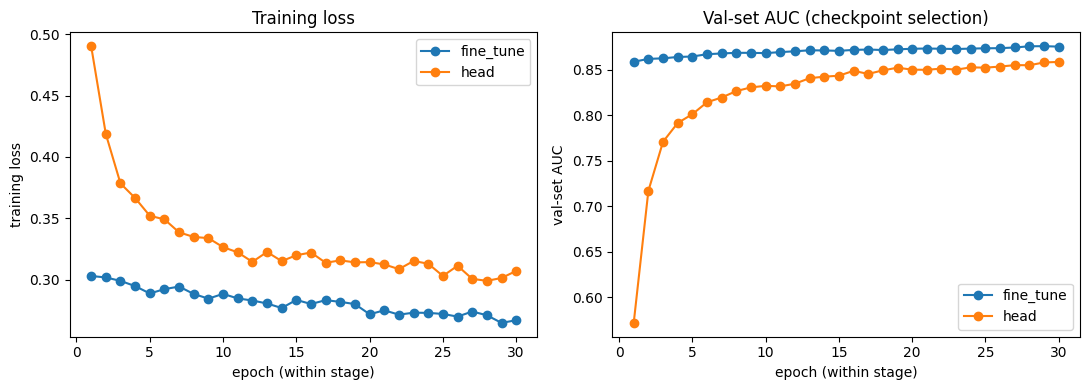

In [12]:
# Plot the training curves (loss and val-set AUC per epoch, per stage).
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for stage, group in history_df.groupby("stage"):
    axes[0].plot(group["epoch"], group["loss"], marker="o", label=stage)
    axes[1].plot(group["epoch"], group["val_auc"], marker="o", label=stage)
axes[0].set_xlabel("epoch (within stage)"); axes[0].set_ylabel("training loss"); axes[0].set_title("Training loss")
axes[1].set_xlabel("epoch (within stage)"); axes[1].set_ylabel("val-set AUC"); axes[1].set_title("Val-set AUC (checkpoint selection)")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=160)
plt.show()

## Calibration, Bayesian Thresholds, and Uncertainty

**Theory â€” calibration.** A classifier is calibrated if, among all cases where it outputs $P(\text{mel})=p$,
roughly a fraction $p$ are truly melanoma. Raw network logits are frequently over-confident; **Platt scaling**
fits a 1-D logistic transform $a\cdot\text{logit} + b$ on a held-out calibration split (`cal_df`, never seen
during training) to correct this. We quantify calibration with the **Expected Calibration Error (ECE)** â€”
the (bin-weighted) average gap between predicted confidence and empirical accuracy â€” and the **Brier score**
(mean squared error of the probability against the 0/1 outcome), and visualize it with a **reliability
diagram**: predicted-probability bins on the x-axis, empirical positive-rate on the y-axis, with the diagonal
as the "perfectly calibrated" reference.

**Theory â€” MC Dropout.** Keeping dropout active at inference time and running $T$ stochastic forward passes
approximates sampling from an approximate posterior over network weights (Gal & Ghahramani, 2016). Averaging
the $T$ probability samples gives the predictive mean; the spread across samples estimates uncertainty. We
decompose total predictive entropy into:
- **Aleatoric uncertainty** (expected entropy of each pass) â€” irreducible ambiguity in the image itself.
- **Epistemic uncertainty** (mutual information between the prediction and the model's own weight
  posterior, a.k.a. BALD) â€” uncertainty that more data or a better model *could* reduce.

High epistemic uncertainty is the signal you'd want to route to manual/expert review rather than trusting
either an automatic "clear" or automatic "urgent" call.

### Calibration and MC-Dropout helper functions

In [13]:
def collect_logits(model, loader):
    model.eval()
    logits_all = []
    targets_all = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(cur_device(), non_blocking=True)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                logits = model(images).squeeze(1)
            logits_all.append(logits.float().cpu())
            targets_all.append(labels.float())
    return torch.cat(logits_all), torch.cat(targets_all)

class PlattScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.a = nn.Parameter(torch.ones(1))
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, logits):
        return self.a * logits + self.b

def fit_platt_scaler(logits, labels):
    scaler_model = PlattScaler()
    criterion_platt = nn.BCEWithLogitsLoss()
    optimizer_platt = torch.optim.LBFGS(scaler_model.parameters(), lr=0.05, max_iter=100)

    def closure():
        optimizer_platt.zero_grad()
        loss = criterion_platt(scaler_model(logits), labels)
        loss.backward()
        return loss

    optimizer_platt.step(closure)
    return float(scaler_model.a.detach().item()), float(scaler_model.b.detach().item())

def apply_platt(logits, a, b):
    return a * logits + b

def enable_dropout(module):
    for child in module.modules():
        if child.__class__.__name__.startswith("Dropout"):
            child.train()

def mc_dropout_predict(model, loader, passes=MC_PASSES, platt_a=1.0, platt_b=0.0):
    model.eval()
    enable_dropout(model)
    all_passes = []
    targets = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(cur_device(), non_blocking=True)
            targets.extend(labels.numpy())
            batch_passes = []
            for _ in range(passes):
                with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                    logits = model(images).squeeze(1)
                calibrated_logits = apply_platt(logits.float(), platt_a, platt_b)
                probs = torch.sigmoid(calibrated_logits).cpu().numpy()
                batch_passes.append(probs)
            all_passes.append(np.stack(batch_passes, axis=0))

    return np.concatenate(all_passes, axis=1), np.asarray(targets)

def uncertainty_from_mc(all_probs):
    predictive_mean = all_probs.mean(axis=0)
    predictive_entropy = -(
        predictive_mean * np.log(predictive_mean + 1e-10)
        + (1 - predictive_mean) * np.log(1 - predictive_mean + 1e-10)
    )
    expected_entropy = np.mean(
        -(all_probs * np.log(all_probs + 1e-10) + (1 - all_probs) * np.log(1 - all_probs + 1e-10)),
        axis=0,
    )
    mutual_information = predictive_entropy - expected_entropy
    return predictive_mean, predictive_entropy, mutual_information

### Fit Platt scaling and run MC-Dropout inference

Platt scaling is fit on the calibration split only; MC-Dropout inference then yields calibrated predictive means and epistemic-uncertainty estimates on the cal and test splits.

In [14]:
# Platt scaling is fit ONLY on the calibration split.
cal_logits, cal_targets_tensor = collect_logits(model, cal_loader)
platt_a, platt_b = fit_platt_scaler(cal_logits, cal_targets_tensor)
print(f"Platt scaling parameters: a={platt_a:.3f}, b={platt_b:.3f}")

cal_all_probs, cal_targets = mc_dropout_predict(model, cal_loader, passes=MC_PASSES, platt_a=platt_a, platt_b=platt_b)
cal_predictive_mean, cal_predictive_entropy, cal_mutual_information = uncertainty_from_mc(cal_all_probs)

# Final reported deep-model metrics come from the held-out test split.
test_all_probs, test_targets = mc_dropout_predict(model, test_loader, passes=MC_PASSES, platt_a=platt_a, platt_b=platt_b)
test_predictive_mean, test_predictive_entropy, test_mutual_information = uncertainty_from_mc(test_all_probs)

# Raw (uncalibrated, single-pass) test probabilities, kept so the reliability diagram can show
# the effect of Platt scaling as a before/after comparison.
raw_test_probs, _ = predict_probs(model, test_loader)

test_auc = roc_auc_score(test_targets, test_predictive_mean)
brier = brier_score_loss(test_targets, test_predictive_mean)
print(f"EfficientNet MC Platt-calibrated TEST AUC: {test_auc:.4f}")
print(f"Brier score (test): {brier:.4f}")

Platt scaling parameters: a=1.082, b=-0.386
EfficientNet MC Platt-calibrated TEST AUC: 0.8581
Brier score (test): 0.0746


### Deep decision rule (MAP vs. asymmetric cost) + operating points + triage zones

### Decision-rule helper functions

In [15]:
def expected_calibration_error(y_true, y_prob, bins=10):
    edges = np.linspace(0.0, 1.0, bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (y_prob > lo) & (y_prob <= hi)
        if not np.any(mask):
            continue
        empirical_rate = y_true[mask].mean()
        confidence = y_prob[mask].mean()
        ece += mask.mean() * abs(empirical_rate - confidence)
    return ece

def find_threshold_for_min_sensitivity(probs, y_true, min_sensitivity=0.98):
    rows = []
    for tau in np.linspace(0.0, 1.0, 1001):
        m = metrics_at_threshold(probs, y_true, tau)
        if m["sensitivity"] >= min_sensitivity:
            rows.append((tau, m))
    if not rows:
        return None
    return max(rows, key=lambda row: row[1]["specificity"])

def selected_threshold_row(cal_probs, cal_y, test_probs, test_y, min_sensitivity, model_name):
    selected = find_threshold_for_min_sensitivity(cal_probs, cal_y, min_sensitivity)
    if selected is None:
        return {"model": model_name, "target_sensitivity": min_sensitivity, "selected_threshold": np.nan}
    tau, cal_m = selected
    test_m = metrics_at_threshold(test_probs, test_y, tau)
    return {
        "model": model_name, "target_sensitivity": min_sensitivity, "selected_threshold": tau,
        "cal_sensitivity": cal_m["sensitivity"], "cal_specificity": cal_m["specificity"],
        "cal_referral_rate": cal_m["referral_rate"],
        "test_sensitivity": test_m["sensitivity"], "test_specificity": test_m["specificity"],
        "test_precision": test_m["precision"], "test_referral_rate": test_m["referral_rate"],
        "test_false_negatives": test_m["false_negatives"], "test_false_positives": test_m["false_positives"],
    }

def triage_zone_summary(probs, mi, y_true, low_threshold, high_threshold=0.5, uncertainty_threshold=None):
    if uncertainty_threshold is None:
        uncertainty_threshold = np.quantile(mi, 0.95)
    low_risk = (probs < low_threshold) & (mi < uncertainty_threshold)
    high_risk = probs >= high_threshold
    manual_review = ~(low_risk | high_risk)
    positives = y_true == 1
    auto_clear_fn = int((low_risk & positives).sum())
    urgent_tp = int((high_risk & positives).sum())
    urgent_fp = int((high_risk & ~positives).sum())
    return {
        "low_threshold": low_threshold, "high_threshold": high_threshold,
        "uncertainty_threshold": uncertainty_threshold,
        "auto_reassured_rate": low_risk.mean(), "manual_review_rate": manual_review.mean(),
        "urgent_referral_rate": high_risk.mean(),
        "false_negatives_auto_reassured": auto_clear_fn,
        "sensitivity_after_auto_reassurance": 1 - (auto_clear_fn / positives.sum() if positives.sum() else 0.0),
        "urgent_referral_precision": urgent_tp / (urgent_tp + urgent_fp) if (urgent_tp + urgent_fp) else 0.0,
    }

### Compute decision metrics, operating points, and triage zones

Cost-sweep table (both models), sensitivity-targeted operating points, calibration errors, and uncertainty-aware triage zones â€” written to CSV and printed.

In [16]:
# --- deep-model cost sweep, appended to the classical rows from earlier for one unified table ---
deep_cost_rows = [
    evaluate_threshold(test_predictive_mean, test_targets, l_fn, l_fp, "deep_efficientnet")
    for l_fn, l_fp in COST_SWEEP
]
cost_comparison_df = pd.concat([classical_cost_df, pd.DataFrame(deep_cost_rows)], ignore_index=True)

operating_point_df = pd.concat([
    pd.DataFrame([selected_threshold_row(gmm_probs_cal, y_cal_gmm, gmm_probs_test, y_test_gmm, s, "classical_gmm")
                  for s in [0.95, 0.98, 0.99]]),
    pd.DataFrame([selected_threshold_row(cal_predictive_mean, cal_targets, test_predictive_mean, test_targets, s, "deep_efficientnet")
                  for s in [0.95, 0.98, 0.99]]),
], ignore_index=True)

ece_test_calibrated = expected_calibration_error(test_targets, test_predictive_mean)
ece_test_raw = expected_calibration_error(test_targets, raw_test_probs)
ece_cal = expected_calibration_error(cal_targets, cal_predictive_mean)
ece_classical = expected_calibration_error(y_test_gmm, gmm_probs_test)
ece_classical_raw = expected_calibration_error(y_test_gmm, gmm_probs_test_raw)

# Uncertainty-aware triage zones (deep model only -- MC Dropout's epistemic-uncertainty
# estimate has no direct classical-GMM analogue in this pipeline; see markdown discussion).
low_threshold_row = operating_point_df.query("model == 'deep_efficientnet' and target_sensitivity == 0.99")
low_threshold = float(low_threshold_row["selected_threshold"].iloc[0]) if len(low_threshold_row) and np.isfinite(low_threshold_row["selected_threshold"].iloc[0]) else tau_cost
uncertainty_threshold = float(np.quantile(cal_mutual_information, 0.95))
triage_zone_df = pd.DataFrame([
    triage_zone_summary(test_predictive_mean, test_mutual_information, test_targets,
                         low_threshold, high_threshold=0.5, uncertainty_threshold=uncertainty_threshold)
])

summary_df = pd.DataFrame([
    {"metric": "classical_gmm_test_auc", "value": auc(gmm_fpr, gmm_tpr)},
    {"metric": "deep_efficientnet_test_auc", "value": test_auc},
    {"metric": "deep_brier_score_test", "value": brier},
    {"metric": "deep_ece_test_calibrated", "value": ece_test_calibrated},
    {"metric": "deep_ece_test_raw", "value": ece_test_raw},
    {"metric": "deep_ece_cal_split", "value": ece_cal},
    {"metric": "classical_ece_test", "value": ece_classical},
    {"metric": "classical_ece_test_raw", "value": ece_classical_raw},
    {"metric": "platt_a", "value": platt_a},
    {"metric": "platt_b", "value": platt_b},
    {"metric": "mc_passes", "value": MC_PASSES},
    {"metric": "fine_tune_backbone", "value": FINE_TUNE_BACKBONE},
    {"metric": "primary_cost_fn_fp", "value": f"{FN_COST}:{FP_COST}"},
    {"metric": "primary_cost_threshold", "value": tau_cost},
])

predictions_df = test_df[["image_id", "lesion_id", "dx", "target"]].copy()
predictions_df["prob_classical_gmm"] = gmm_probs_test
predictions_df["prob_deep_efficientnet"] = test_predictive_mean
predictions_df["predictive_entropy"] = test_predictive_entropy
predictions_df["mutual_information"] = test_mutual_information
low_risk_mask = (test_predictive_mean < low_threshold) & (test_mutual_information < uncertainty_threshold)
high_risk_mask = test_predictive_mean >= 0.5
predictions_df["triage_zone"] = np.select(
    [low_risk_mask, high_risk_mask],
    ["low_risk_auto_reassure", "high_risk_urgent_referral"],
    default="manual_review",
)

cost_comparison_df.to_csv(OUTPUT_DIR / "cost_sweep_comparison.csv", index=False)
operating_point_df.to_csv(OUTPUT_DIR / "sensitivity_operating_points.csv", index=False)
triage_zone_df.to_csv(OUTPUT_DIR / "triage_zone_metrics.csv", index=False)
summary_df.to_csv(OUTPUT_DIR / "summary_metrics.csv", index=False)
predictions_df.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

print(f"Deep TEST ECE: calibrated={ece_test_calibrated:.4f} vs raw={ece_test_raw:.4f} "
      f"(lower is better; compare to see whether Platt scaling helped)")
print(f"Classical TEST ECE: {ece_classical:.4f}")
print("\nUnified cost-sensitive decision comparison (classical vs. deep, same test lesions):")
print(cost_comparison_df.to_string(index=False, formatters={
    "threshold": "{:.3f}".format, "sensitivity": "{:.3f}".format,
    "specificity": "{:.3f}".format, "precision": "{:.3f}".format, "referral_rate": "{:.3f}".format,
}))
print("\nSensitivity-targeted operating points (threshold picked on cal/val, evaluated on test):")
print(operating_point_df.to_string(index=False))
print("\nUncertainty-aware triage zones (deep model, test set):")
print(triage_zone_df.to_string(index=False))
print(f"\nSaved metrics and predictions to {OUTPUT_DIR.resolve()}")

Deep TEST ECE: calibrated=0.0155 vs raw=0.0374 (lower is better; compare to see whether Platt scaling helped)
Classical TEST ECE: 0.0124

Unified cost-sensitive decision comparison (classical vs. deep, same test lesions):
            model cost_ratio_fn_fp threshold sensitivity specificity precision referral_rate  false_negatives  false_positives  true_negatives  true_positives
    classical_gmm              1:1     0.500       0.010       0.997     0.286         0.004              198                5            1655               2
    classical_gmm              5:1     0.167       0.635       0.808     0.285         0.240               73              319            1341             127
    classical_gmm             10:1     0.091       0.875       0.572     0.198         0.476               25              711             949             175
    classical_gmm             20:1     0.048       0.950       0.448     0.172         0.595               10              916             744

## Expected Output: ROC Curves

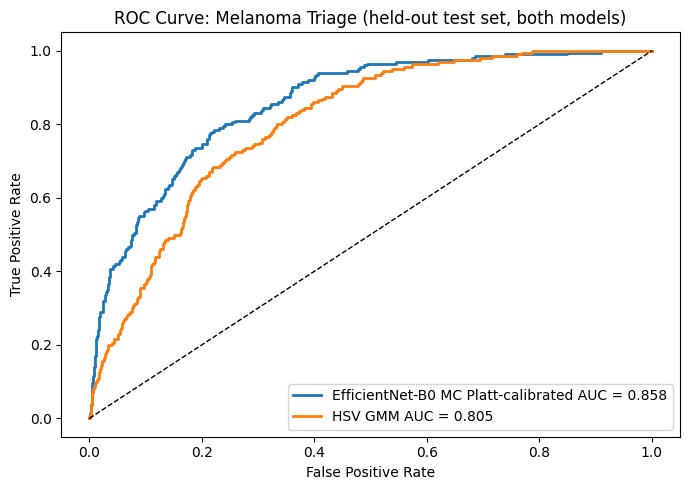

In [17]:
fpr, tpr, _ = roc_curve(test_targets, test_predictive_mean)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, lw=2, label=f"EfficientNet-B0 MC Platt-calibrated AUC = {auc(fpr, tpr):.3f}")
plt.plot(gmm_fpr, gmm_tpr, lw=2, label=f"HSV GMM AUC = {auc(gmm_fpr, gmm_tpr):.3f}")
plt.plot([0, 1], [0, 1], color="black", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Melanoma Triage (held-out test set, both models)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve_triage.png", dpi=160)
plt.show()

## Reliability / Calibration Analysis

The reliability diagram plots predicted-probability bins against the empirical melanoma rate, with
the diagonal as the perfectly-calibrated reference. Three curves are shown â€” the classical GMM, the
deep model's raw logits, and the deep model after Platt scaling â€” so the effect of calibration is
visible directly.

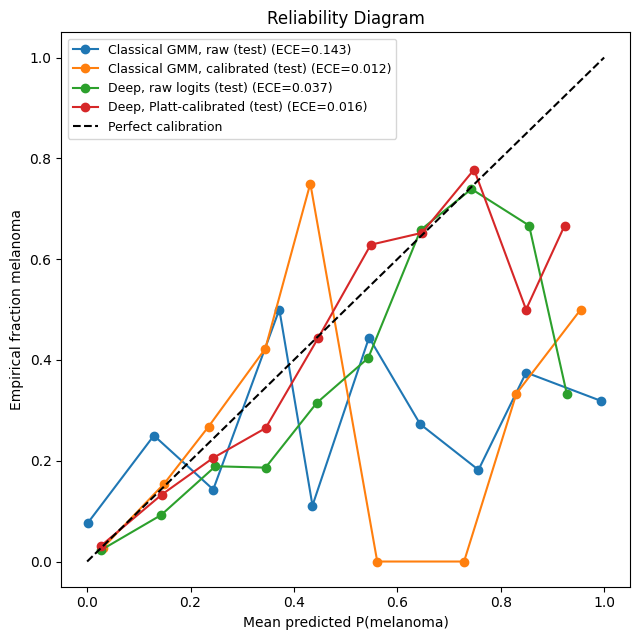

In [18]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
curves = [
    ("Classical GMM, raw (test)", y_test_gmm, gmm_probs_test_raw, ece_classical_raw),
    ("Classical GMM, calibrated (test)", y_test_gmm, gmm_probs_test, ece_classical),
    ("Deep, raw logits (test)", test_targets, raw_test_probs, ece_test_raw),
    ("Deep, Platt-calibrated (test)", test_targets, test_predictive_mean, ece_test_calibrated),
]
for label, y_true, y_prob, ece_value in curves:
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac_pos, marker="o", label=f"{label} (ECE={ece_value:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted P(melanoma)")
ax.set_ylabel("Empirical fraction melanoma")
ax.set_title("Reliability Diagram")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "reliability_diagram.png", dpi=160)
plt.show()

## Confusion Matrices

Each model is shown at both its MAP threshold (0.5) and its primary asymmetric-cost threshold, so
the shift in false negatives/positives from changing the decision rule is visible directly.

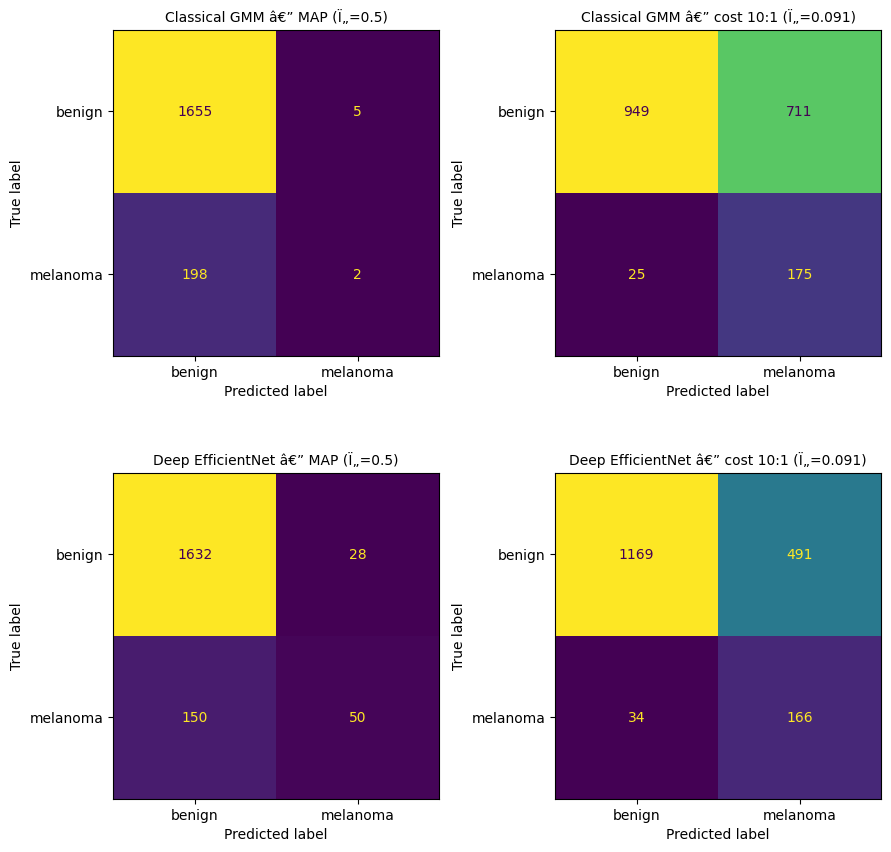

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
combos = [
    ("Classical GMM â€” MAP (Ï„=0.5)", y_test_gmm, gmm_probs_test, tau_map),
    (f"Classical GMM â€” cost {FN_COST}:{FP_COST} (Ï„={tau_cost:.3f})", y_test_gmm, gmm_probs_test, tau_cost),
    ("Deep EfficientNet â€” MAP (Ï„=0.5)", test_targets, test_predictive_mean, tau_map),
    (f"Deep EfficientNet â€” cost {FN_COST}:{FP_COST} (Ï„={tau_cost:.3f})", test_targets, test_predictive_mean, tau_cost),
]
for ax, (title, y_true, y_prob, tau) in zip(axes.ravel(), combos):
    preds = (y_prob >= tau).astype(int)
    cm = confusion_matrix(y_true, preds, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["benign", "melanoma"]).plot(ax=ax, colorbar=False)
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=160)
plt.show()

## Expected Output: Uncertainty Examples

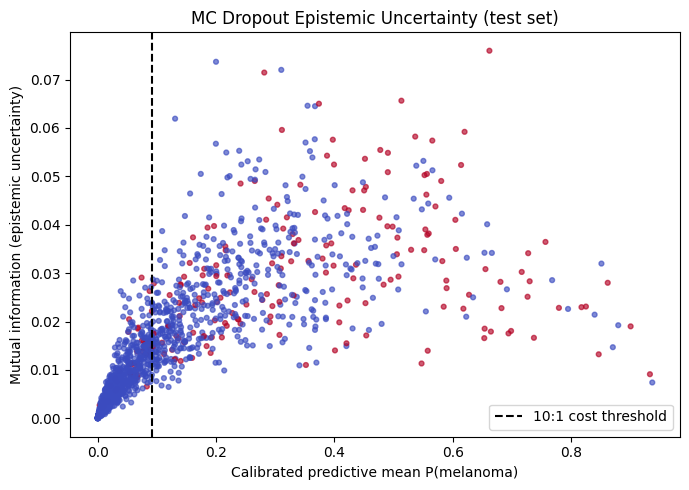

In [20]:
# The threshold line uses the computed tau_cost, so it always matches FN_COST/FP_COST.
plt.figure(figsize=(7, 5))
plt.scatter(test_predictive_mean, test_mutual_information, c=test_targets, cmap="coolwarm", s=12, alpha=0.65)
plt.axvline(tau_cost, color="black", linestyle="--", label=f"{FN_COST}:{FP_COST} cost threshold")
plt.xlabel("Calibrated predictive mean P(melanoma)")
plt.ylabel("Mutual information (epistemic uncertainty)")
plt.title("MC Dropout Epistemic Uncertainty (test set)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "uncertainty_scatter.png", dpi=160)
plt.show()

## Comparison of Classical and Deep Triage Decisions

Both models' decisions are computed on the *same* held-out test lesions at the same asymmetric-cost
threshold, which lets us measure their agreement and identify the lesions they disagree on.

Agreement rate at the 10:1 cost threshold: 0.731
Melanomas missed by BOTH models: 5
Referred by classical only: 365; referred by deep only: 136


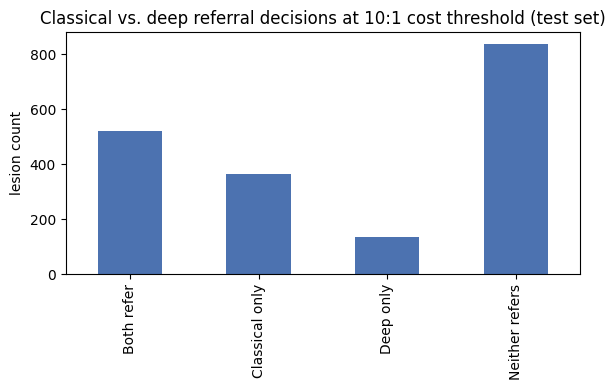

In [21]:
comparison_df = test_df[["image_id", "lesion_id", "dx", "target"]].copy()
comparison_df["prob_classical"] = gmm_probs_test
comparison_df["prob_deep"] = test_predictive_mean
comparison_df["mutual_information"] = test_mutual_information
comparison_df["decision_classical"] = (gmm_probs_test >= tau_cost).astype(int)
comparison_df["decision_deep"] = (test_predictive_mean >= tau_cost).astype(int)
comparison_df["agree"] = comparison_df["decision_classical"] == comparison_df["decision_deep"]
comparison_df.to_csv(OUTPUT_DIR / "classical_vs_deep_predictions.csv", index=False)

agree_rate = comparison_df["agree"].mean()
both_miss = ((comparison_df["target"] == 1) & (comparison_df["decision_classical"] == 0) & (comparison_df["decision_deep"] == 0)).sum()
classical_only_referral = ((comparison_df["decision_classical"] == 1) & (comparison_df["decision_deep"] == 0)).sum()
deep_only_referral = ((comparison_df["decision_deep"] == 1) & (comparison_df["decision_classical"] == 0)).sum()

print(f"Agreement rate at the {FN_COST}:{FP_COST} cost threshold: {agree_rate:.3f}")
print(f"Melanomas missed by BOTH models: {both_miss}")
print(f"Referred by classical only: {classical_only_referral}; referred by deep only: {deep_only_referral}")

fig, ax = plt.subplots(figsize=(6, 4))
counts = pd.Series({
    "Both refer": ((comparison_df.decision_classical == 1) & (comparison_df.decision_deep == 1)).sum(),
    "Classical only": classical_only_referral,
    "Deep only": deep_only_referral,
    "Neither refers": ((comparison_df.decision_classical == 0) & (comparison_df.decision_deep == 0)).sum(),
})
counts.plot(kind="bar", ax=ax, color="#4c72b0")
ax.set_ylabel("lesion count")
ax.set_title(f"Classical vs. deep referral decisions at {FN_COST}:{FP_COST} cost threshold (test set)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "classical_vs_deep_decisions.png", dpi=160)
plt.show()

### Example Gallery (successes and failures)

A gallery spanning both successes and failures: a clean low-risk benign, a clean urgent melanoma, a
near-threshold case, the most epistemically uncertain case, an explicit false negative, an explicit
false positive, and a case where the classical and deep models disagree.

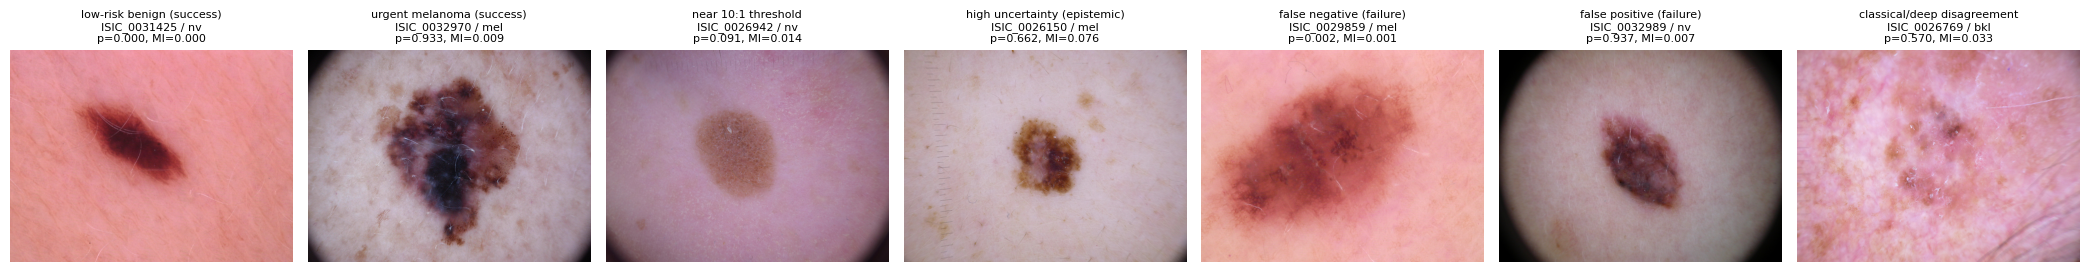

In [22]:
def first_or_none(frame):
    return frame.iloc[0] if len(frame) else None

example_specs = [
    ("low-risk benign (success)", predictions_df.sort_values("prob_deep_efficientnet").query("target == 0").head(1)),
    ("urgent melanoma (success)", predictions_df.sort_values("prob_deep_efficientnet", ascending=False).query("target == 1").head(1)),
    (f"near {FN_COST}:{FP_COST} threshold", predictions_df.iloc[(predictions_df["prob_deep_efficientnet"] - tau_cost).abs().argsort()].head(1)),
    ("high uncertainty (epistemic)", predictions_df.sort_values("mutual_information", ascending=False).head(1)),
    ("false negative (failure)", predictions_df.query("target == 1 and prob_deep_efficientnet < @tau_cost")
        .sort_values("prob_deep_efficientnet").head(1)),
    ("false positive (failure)", predictions_df.query("target == 0 and prob_deep_efficientnet >= @tau_cost")
        .sort_values("prob_deep_efficientnet", ascending=False).head(1)),
    ("classical/deep disagreement", comparison_df.query("not agree").head(1)),
]
example_specs = [(role, frame) for role, frame in example_specs if len(frame)]

fig, axes = plt.subplots(1, len(example_specs), figsize=(3.0 * len(example_specs), 3.4))
if len(example_specs) == 1:
    axes = [axes]
path_lookup = test_df.set_index("image_id")["image_path"].to_dict()

for ax, (role, frame) in zip(axes, example_specs):
    row = frame.iloc[0]
    image = Image.open(path_lookup[row["image_id"]]).convert("RGB")
    ax.imshow(image)
    ax.axis("off")
    prob_col = "prob_deep_efficientnet" if "prob_deep_efficientnet" in row else "prob_deep"
    mi_val = row["mutual_information"] if "mutual_information" in row else float("nan")
    ax.set_title(f"{role}\n{row['image_id']} / {row['dx']}\np={row[prob_col]:.3f}, MI={mi_val:.3f}", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "example_lesions_grid.png", dpi=180)
plt.show()

## Diagnostics: BIC Curves for GMM Component Selection

The BIC curve for each class, with the selected component count marked. A minimum near the edge of
the search range is a sign that the range should be widened or that the fit is unstable â€” worth
watching for the smaller melanoma class. A fresh figure is created per class and saved before
display.

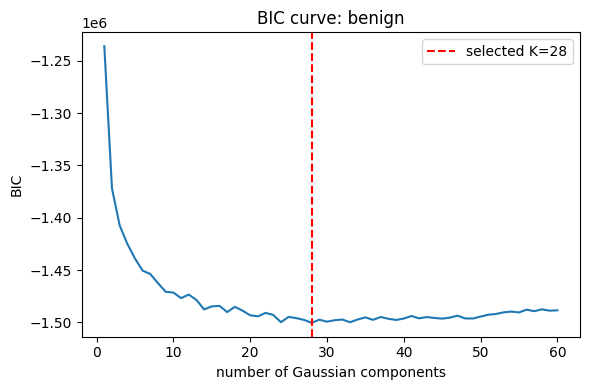

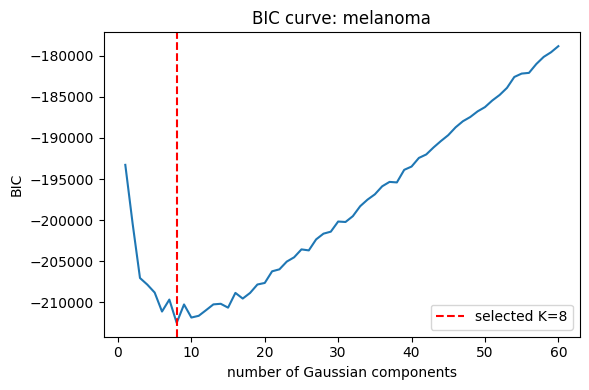

In [23]:
# x-axis length matches each class's own (possibly sample-size-capped) search range.
fig1 = plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, class_max_k[0] + 1), np.array(bic_scores[0]))
plt.axvline(k_benign, color="red", linestyle="--", label=f"selected K={k_benign}")
plt.xlabel("number of Gaussian components")
plt.ylabel("BIC")
plt.title("BIC curve: benign")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bic_curve_benign.png", dpi=160)
plt.show()

fig2 = plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, class_max_k[1] + 1), np.array(bic_scores[1]))
plt.axvline(k_mel, color="red", linestyle="--", label=f"selected K={k_mel}")
plt.xlabel("number of Gaussian components")
plt.ylabel("BIC")
plt.title("BIC curve: melanoma")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bic_curve_melanoma.png", dpi=160)
plt.show()

## Reproducibility Metadata

Saves the seed, feature configuration, selected GMM component counts, cost matrix, package
versions, split sizes, and wall-clock runtime the run used to `run_config.json`.

In [24]:
total_runtime_seconds = time.time() - NOTEBOOK_START_TIME
run_config = {
    "seeds": SEEDS,
    "seed": SEED,
    "hsv_bins": HSV_BINS,
    "gmm_max_components_searched": GMM_MAX_COMPONENTS,
    "gmm_calibrated": True,
    "gmm_selected_k": {"benign": k_benign, "melanoma": k_mel},
    "gmm_fit_subsample_size": int(_gmm_fit_n),
    "primary_cost_matrix": {"fn_cost": FN_COST, "fp_cost": FP_COST, "tau": tau_cost},
    "cost_sweep_ratios": COST_SWEEP,
    "fine_tune_backbone": FINE_TUNE_BACKBONE,
    "head_epochs": HEAD_EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS if FINE_TUNE_BACKBONE else 0,
    "unfreeze_last_blocks": UNFREEZE_LAST_BLOCKS if FINE_TUNE_BACKBONE else 0,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "mc_dropout_passes": MC_PASSES,
    "batch_size": BATCH_SIZE,
    "runtime_minutes": {
        "head_training": round(head_train_seconds / 60, 2),
        "fine_tuning": round(fine_tune_seconds / 60, 2),
        "total_notebook_so_far": round(total_runtime_seconds / 60, 2),
    },
    "split_sizes": {
        "fit": len(fit_df), "val": len(val_df), "cal": len(cal_df), "test": len(test_df),
    },
    "package_versions": {
        "python": platform.python_version(), "torch": torch.__version__,
        "sklearn": sklearn.__version__, "opencv": cv2.__version__,
        "pandas": pd.__version__, "numpy": np.__version__,
    },
}
with open(OUTPUT_DIR / "run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)
print(json.dumps(run_config, indent=2))

{
  "seeds": [
    42,
    1,
    2
  ],
  "seed": 42,
  "hsv_bins": 32,
  "gmm_max_components_searched": 60,
  "gmm_calibrated": true,
  "gmm_selected_k": {
    "benign": 28,
    "melanoma": 8
  },
  "gmm_fit_subsample_size": 2000,
  "primary_cost_matrix": {
    "fn_cost": 10,
    "fp_cost": 1,
    "tau": 0.09090909090909091
  },
  "cost_sweep_ratios": [
    [
      1,
      1
    ],
    [
      5,
      1
    ],
    [
      10,
      1
    ],
    [
      20,
      1
    ]
  ],
  "fine_tune_backbone": true,
  "head_epochs": 30,
  "fine_tune_epochs": 30,
  "unfreeze_last_blocks": 2,
  "early_stop_patience": 5,
  "mc_dropout_passes": 30,
  "batch_size": 256,
  "runtime_minutes": {
    "head_training": 8.47,
    "fine_tuning": 8.15,
    "total_notebook_so_far": 22.6
  },
  "split_sizes": {
    "fit": 4750,
    "val": 1146,
    "cal": 1418,
    "test": 1860
  },
  "package_versions": {
    "python": "3.12.12",
    "torch": "2.10.0+cu128",
    "sklearn": "1.6.1",
    "opencv": "4.13.0",
  

## Outputs

The notebook writes all downloadable artifacts to `/kaggle/working/outputs/`:

- `split_assignment.csv` â€” exact fit/val/cal/test membership per image (reproducibility)
- `training_history.csv`, `training_curves.png`
- `class_balance.png`
- `raw_vs_processed_feature.png`
- `bayes_decision_boundary.png`
- `bic_curve_benign.png`, `bic_curve_melanoma.png`
- `roc_curve_triage.png`
- `reliability_diagram.png`
- `confusion_matrices.png`
- `uncertainty_scatter.png`
- `classical_vs_deep_decisions.png`, `classical_vs_deep_predictions.csv`
- `example_lesions_grid.png`
- `cost_sweep_comparison.csv` â€” classical + deep at MAP and asymmetric-cost thresholds
- `sensitivity_operating_points.csv`
- `triage_zone_metrics.csv`
- `summary_metrics.csv`
- `test_predictions.csv`
- `run_config.json` â€” seed, split sizes, GMM K, cost matrix, package versions

Download the `outputs/` folder from Kaggle and copy it into `experiments/outputs/` to refresh the
committed results.

## Multi-seed robustness

Re-run the full pipeline (split, GMM+Platt, EfficientNet training, calibration, decisions) for every seed in `SEEDS` and report mean +/- std of the headline metrics. The primary seed (`SEEDS[0]`) is reused from above; only the remaining seeds are trained here.

In [25]:
# Reuse the helper functions defined above so the multi-seed loop matches the primary flow exactly.
def collect_metrics(seed, y_test_gmm, gmm_test, gmm_cal, y_cal_gmm,
                    test_targets, test_mean, cal_targets, cal_mean, test_mi, cal_mi,
                    gmm_auc, deep_auc, brier, ece_deep_cal, ece_deep_raw, ece_gmm_cal, ece_gmm_raw):
    summary = {"seed": seed, "gmm_test_auc": gmm_auc, "deep_test_auc": deep_auc,
               "deep_brier": brier, "deep_ece_cal": ece_deep_cal, "deep_ece_raw": ece_deep_raw,
               "gmm_ece_cal": ece_gmm_cal, "gmm_ece_raw": ece_gmm_raw}
    cost = []
    for l_fn, l_fp in COST_SWEEP:
        cost.append({**evaluate_threshold(gmm_test, y_test_gmm, l_fn, l_fp, "classical_gmm"), "seed": seed})
        cost.append({**evaluate_threshold(test_mean, test_targets, l_fn, l_fp, "deep_efficientnet"), "seed": seed})
    ops = []
    for s in [0.95, 0.98, 0.99]:
        ops.append({**selected_threshold_row(gmm_cal, y_cal_gmm, gmm_test, y_test_gmm, s, "classical_gmm"), "seed": seed})
        ops.append({**selected_threshold_row(cal_mean, cal_targets, test_mean, test_targets, s, "deep_efficientnet"), "seed": seed})
    op99 = [r for r in ops if r["model"] == "deep_efficientnet" and r["target_sensitivity"] == 0.99][0]
    low_thr = op99.get("selected_threshold", np.nan)
    if not (isinstance(low_thr, (int, float)) and np.isfinite(low_thr)):
        low_thr = FP_COST / (FP_COST + FN_COST)
    unc_thr = float(np.quantile(cal_mi, 0.95))
    triage = {**triage_zone_summary(test_mean, test_mi, test_targets, low_thr, 0.5, unc_thr), "seed": seed}
    return {"summary": summary, "cost": cost, "ops": ops, "triage": triage}

def run_pipeline(seed, gpu_id=None):
    if gpu_id is not None and torch.cuda.is_available():
        _device_tls.device = torch.device(f"cuda:{gpu_id}")   # pin this thread to one GPU
    concurrent = gpu_id is not None
    tag = f"[seed {seed}" + (f" cuda:{gpu_id}] " if concurrent else "] ")
    workers = max(1, NUM_WORKERS // 2) if concurrent else NUM_WORKERS
    print(f"{tag}starting", flush=True)
    fit_d, val_d, cal_d, test_d = make_splits(trainpool_df, seed)
    fl, vl, cl, tl = build_loaders(fit_d, val_d, cal_d, test_d,
                                   num_workers=workers, gen=torch.Generator().manual_seed(seed))
    m, _, _, _ = train_efficientnet(fl, vl, seed, tag=tag, batch_progress=not concurrent)
    cal_logits, cal_t = collect_logits(m, cl)
    a, b = fit_platt_scaler(cal_logits, cal_t)
    cal_all, cal_targets = mc_dropout_predict(m, cl, MC_PASSES, a, b)
    cal_mean, _, cal_mi = uncertainty_from_mc(cal_all)
    test_all, test_targets = mc_dropout_predict(m, tl, MC_PASSES, a, b)
    test_mean, _, test_mi = uncertainty_from_mc(test_all)
    raw_test, _ = predict_probs(m, tl)
    deep_auc = roc_auc_score(test_targets, test_mean)
    brier = brier_score_loss(test_targets, test_mean)
    ece_deep_cal = expected_calibration_error(test_targets, test_mean)
    ece_deep_raw = expected_calibration_error(test_targets, raw_test)
    g = fit_calibrated_gmm(fit_d, cal_d, seed)
    Xte = np.stack([extract_hsv_hist(p) for p in test_d["image_path"]]); yte = test_d["target"].to_numpy()
    Xca = np.stack([extract_hsv_hist(p) for p in cal_d["image_path"]]); yca = cal_d["target"].to_numpy()
    gmm_test = g["prob_cal"](Xte); gmm_cal = g["prob_cal"](Xca); gmm_test_raw = g["prob_raw"](Xte)
    gmm_auc = roc_auc_score(yte, gmm_test)
    ece_gmm_cal = expected_calibration_error(yte, gmm_test)
    ece_gmm_raw = expected_calibration_error(yte, gmm_test_raw)
    print(f"{tag}done (deep test AUC {deep_auc:.3f}, gmm {gmm_auc:.3f})", flush=True)
    return collect_metrics(seed, yte, gmm_test, gmm_cal, yca, test_targets, test_mean,
                           cal_targets, cal_mean, test_mi, cal_mi, gmm_auc, deep_auc, brier,
                           ece_deep_cal, ece_deep_raw, ece_gmm_cal, ece_gmm_raw)

# Package the already-trained primary seed, then train only the extra seeds.
metrics_seed0 = collect_metrics(
    SEEDS[0], y_test_gmm, gmm_probs_test, gmm_probs_cal, y_cal_gmm,
    test_targets, test_predictive_mean, cal_targets, cal_predictive_mean,
    test_mutual_information, cal_mutual_information,
    auc(gmm_fpr, gmm_tpr), test_auc, brier,
    ece_test_calibrated, ece_test_raw, ece_classical, ece_classical_raw,
)
# Free the primary-seed loaders + their persistent workers so the two concurrent runs don't
# stack their prefetch buffers on top of the primary ones (this was the host-RAM OOM).
import gc
for _ldr in ["fit_loader", "val_loader", "cal_loader", "test_loader"]:
    globals().pop(_ldr, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

import concurrent.futures as _cf
_extra = SEEDS[1:]
if torch.cuda.is_available() and GPU_COUNT >= 2 and len(_extra) > 1:
    print(f"Training {len(_extra)} extra seeds concurrently, one per GPU across {GPU_COUNT} GPUs...")
    with _cf.ThreadPoolExecutor(max_workers=min(GPU_COUNT, len(_extra))) as _ex:
        _futs = [_ex.submit(run_pipeline, s, i % GPU_COUNT) for i, s in enumerate(_extra)]
        _extra_metrics = [f.result() for f in _futs]   # ordered by submission (seed order)
else:
    _extra_metrics = [run_pipeline(s) for s in _extra]
all_metrics = [metrics_seed0] + _extra_metrics

def _agg(frame, group_cols):
    num = [c for c in frame.select_dtypes("number").columns if c != "seed"]
    g = frame.groupby(group_cols)[num]
    return g.mean().add_suffix("_mean").join(g.std(ddof=0).add_suffix("_std")).reset_index()

def _agg_flat(frame):
    f = frame.drop(columns="seed")
    return pd.concat([f.mean().rename("mean"), f.std(ddof=0).rename("std")], axis=1).reset_index(names="metric")

summary_seeds = pd.DataFrame([m["summary"] for m in all_metrics])
cost_seeds = pd.DataFrame([r for m in all_metrics for r in m["cost"]])
ops_seeds = pd.DataFrame([r for m in all_metrics for r in m["ops"]])
triage_seeds = pd.DataFrame([m["triage"] for m in all_metrics])

summary_seeds.to_csv(OUTPUT_DIR / "seed_variance_raw_summary.csv", index=False)
_agg_flat(summary_seeds).to_csv(OUTPUT_DIR / "seed_variance_summary.csv", index=False)
_agg(cost_seeds, ["model", "cost_ratio_fn_fp"]).to_csv(OUTPUT_DIR / "seed_variance_cost_sweep.csv", index=False)
_agg(ops_seeds, ["model", "target_sensitivity"]).to_csv(OUTPUT_DIR / "seed_variance_operating_points.csv", index=False)
_agg_flat(triage_seeds).to_csv(OUTPUT_DIR / "seed_variance_triage.csv", index=False)

print(f"\nSeeds: {SEEDS}")
print("\nAUC / calibration (mean +/- std across seeds):")
print(_agg_flat(summary_seeds).to_string(index=False))
print("\nCost-sweep sensitivity/specificity (mean +/- std across seeds):")
print(_agg(cost_seeds, ["model", "cost_ratio_fn_fp"]).to_string(index=False))
print(f"\nSaved seed_variance_*.csv to {OUTPUT_DIR.resolve()}")


Training 2 extra seeds concurrently, one per GPU across 2 GPUs...
[seed 1 cuda:0] starting
[seed 2 cuda:1] starting
[seed 1 cuda:0] head 01/30 - loss 0.4706 - val_auc 0.4677 *
[seed 2 cuda:1] head 01/30 - loss 0.4833 - val_auc 0.4963 *
[seed 1 cuda:0] head 02/30 - loss 0.3855 - val_auc 0.6277 *
[seed 2 cuda:1] head 02/30 - loss 0.3983 - val_auc 0.6330 *
[seed 1 cuda:0] head 03/30 - loss 0.3634 - val_auc 0.7013 *
[seed 2 cuda:1] head 03/30 - loss 0.3641 - val_auc 0.7101 *
[seed 1 cuda:0] head 04/30 - loss 0.3468 - val_auc 0.7284 *
[seed 2 cuda:1] head 04/30 - loss 0.3523 - val_auc 0.7221 *
[seed 1 cuda:0] head 05/30 - loss 0.3387 - val_auc 0.7399 *
[seed 2 cuda:1] head 05/30 - loss 0.3369 - val_auc 0.7468 *
[seed 1 cuda:0] head 06/30 - loss 0.3250 - val_auc 0.7552 *
[seed 2 cuda:1] head 06/30 - loss 0.3301 - val_auc 0.7569 *
[seed 1 cuda:0] head 07/30 - loss 0.3179 - val_auc 0.7661 *
[seed 2 cuda:1] head 07/30 - loss 0.3275 - val_auc 0.7626 *
[seed 1 cuda:0] head 08/30 - loss 0.3184 - v

In [26]:
from IPython.display import FileLink, FileLinks, display
import shutil

output_dir = OUTPUT_DIR.resolve()
archive_path = shutil.make_archive(str(output_dir), "zip", root_dir=output_dir)

print(f"Output directory: {output_dir}")
print(f"Created archive: {archive_path}")

Output directory: /kaggle/working/outputs
Created archive: /kaggle/working/outputs.zip
